# 04 — Polynomials

**Topic 4 of the math journey.** A **polynomial** is the most important kind of algebraic
expression: a sum of powers of a variable with number coefficients. Polynomials are the
"nice" functions — easy to add, multiply, and differentiate later — and they appear
everywhere (curve fitting, neural-network activations, Taylor approximations). Today we
define them carefully, learn the operations, and prove the key identities.

## Quick recall (answers)
- Distance between $(2,3)$ and $(7,15)$: $\sqrt{(7-2)^2+(15-3)^2}=\sqrt{25+144}=\sqrt{169}=13$.
- Legs 6 and 8: hypotenuse $=\sqrt{6^2+8^2}=\sqrt{100}=10$.

## What we cover today
1. What a polynomial is: terms, degree, coefficients, standard form.
2. Adding and subtracting polynomials.
3. Multiplying polynomials (distributive law, FOIL).
4. Special products and their proofs (squares, difference of squares).
5. The degree rules for sums and products (with proof).
6. Evaluating polynomials, and what their graphs look like.


## 1. What is a polynomial?

A **polynomial in $x$** is a finite sum
$$ p(x) = a_n x^n + a_{n-1}x^{n-1} + \dots + a_1 x + a_0, $$
where the **coefficients** $a_n,\dots,a_0$ are numbers and the exponents are
**non-negative whole numbers** (so no $x^{-1}$, no $\sqrt{x}$, no $x$ in a denominator).

Vocabulary:
- Each piece $a_k x^k$ is a **term**; $a_k$ is its **coefficient**.
- The **degree** is the highest power with a non-zero coefficient.
- The coefficient of that highest power is the **leading coefficient**; $a_0$ is the
  **constant term**.
- **Standard form** = terms written from highest power to lowest.

Names by number of terms: **monomial** (1 term), **binomial** (2), **trinomial** (3).
Names by degree: degree 1 = **linear**, 2 = **quadratic**, 3 = **cubic**.

Example: $p(x) = 2x^3 - 5x + 7$ is a cubic trinomial; leading coefficient $2$, degree $3$,
constant term $7$.


In [1]:
import sympy as sp                     # sympy = exact symbolic algebra

x = sp.symbols('x')
p = 2*x**3 - 5*x + 7
P = sp.Poly(p, x)                        # sp.Poly views the expression AS a polynomial in x

print("polynomial:        ", p)
print("degree:            ", P.degree())         # highest power = 3
print("leading coeff:     ", P.LC())             # LC = leading coefficient = 2
print("all coefficients:  ", P.all_coeffs())     # [2, 0, -5, 7]  (note the 0 for the missing x^2)
print("constant term:     ", p.subs(x, 0))       # plug x=0 to read off a_0 = 7


polynomial:         2*x**3 - 5*x + 7
degree:             3
leading coeff:      2
all coefficients:   [2, 0, -5, 7]
constant term:      7


## 2. Adding and subtracting polynomials

To add or subtract, **combine like terms** (same power) — exactly the distributive-law
idea from lesson 2. Line up matching powers and add their coefficients.

Example:
$$ (3x^2 - 2x + 1) + (x^2 + 5x - 4) = (3+1)x^2 + (-2+5)x + (1-4) = 4x^2 + 3x - 3. $$

Subtraction: distribute the minus sign first.
$$ (3x^2 - 2x + 1) - (x^2 + 5x - 4) = 2x^2 - 7x + 5. $$


In [2]:
import sympy as sp
x = sp.symbols('x')

A = 3*x**2 - 2*x + 1
B = x**2 + 5*x - 4

print("A + B =", sp.expand(A + B))       # sp.expand multiplies out and collects like terms
print("A - B =", sp.expand(A - B))


A + B = 4*x**2 + 3*x - 3
A - B = 2*x**2 - 7*x + 5


## 3. Multiplying polynomials

Multiply **every** term of the first by **every** term of the second (the distributive law
used many times), then combine like terms.

For two binomials there is a memory word, **FOIL** (First, Outer, Inner, Last):
$$ (x+3)(x+5) = \underbrace{x\cdot x}_{F} + \underbrace{x\cdot 5}_{O} + \underbrace{3\cdot x}_{I} + \underbrace{3\cdot5}_{L} = x^2 + 8x + 15. $$

FOIL is just the distributive law; for bigger polynomials there is no shortcut — multiply
each-by-each.


In [3]:
import sympy as sp
x = sp.symbols('x')

print("(x+3)(x+5)      =", sp.expand((x + 3)*(x + 5)))
print("(2x-1)(x^2+4x-3)=", sp.expand((2*x - 1)*(x**2 + 4*x - 3)))

# Show FOIL piece by piece so you can SEE the four products:
a, b, c, d = x, 3, x, 5
print("F,O,I,L parts:", a*c, "+", a*d, "+", b*c, "+", b*d)


(x+3)(x+5)      = x**2 + 8*x + 15
(2x-1)(x^2+4x-3)= 2*x**3 + 7*x**2 - 10*x + 3
F,O,I,L parts: x**2 + 5*x + 3*x + 15


## 4. Special products (memorize these — and here is why they are true)

These three identities come up constantly.

**(i) Square of a sum:** $\;(a+b)^2 = a^2 + 2ab + b^2.$
**Proof.** $(a+b)^2 = (a+b)(a+b) = a\cdot a + a\cdot b + b\cdot a + b\cdot b
= a^2 + ab + ab + b^2 = a^2 + 2ab + b^2$ (using FOIL, then $ab=ba$). ∎

**(ii) Square of a difference:** $\;(a-b)^2 = a^2 - 2ab + b^2.$ (Same proof with $-b$.)

**(iii) Difference of squares:** $\;(a+b)(a-b) = a^2 - b^2.$
**Proof.** $(a+b)(a-b) = a^2 - ab + ba - b^2 = a^2 - ab + ab - b^2 = a^2 - b^2$; the middle
terms cancel. ∎

The difference-of-squares identity is the seed of **factoring** (next lesson): it lets you
turn $a^2 - b^2$ *back* into $(a+b)(a-b)$.


In [4]:
import sympy as sp
a, b = sp.symbols('a b')

# Verify each identity: expand the left side and compare to the claimed right side.
print("(a+b)^2 =", sp.expand((a + b)**2))
print("(a-b)^2 =", sp.expand((a - b)**2))
print("(a+b)(a-b) =", sp.expand((a + b)*(a - b)))

# "== 0 after subtracting" is the rigorous check that they are ALWAYS equal:
print("identity (i) holds?", sp.expand((a+b)**2 - (a**2 + 2*a*b + b**2)) == 0)


(a+b)^2 = a**2 + 2*a*b + b**2
(a-b)^2 = a**2 - 2*a*b + b**2
(a+b)(a-b) = a**2 - b**2
identity (i) holds? True


## 5. Degree rules

Let $p$ and $q$ be non-zero polynomials.

**Theorem (degree of a product).** $\deg(pq) = \deg(p) + \deg(q)$.

**Proof.** Say $\deg p = m$ with leading term $a_m x^m$ ($a_m\neq0$), and $\deg q = n$ with
leading term $b_n x^n$ ($b_n\neq0$). When we multiply, the highest power that can appear is
$x^{m}\cdot x^{n} = x^{m+n}$, and it comes **only** from multiplying the two leading terms,
giving coefficient $a_m b_n$. Since $a_m\neq0$ and $b_n\neq0$ (real numbers, no zero
divisors — lesson 2 exercise), we have $a_m b_n \neq 0$. So $x^{m+n}$ really survives and
is the highest power: $\deg(pq)=m+n$. ∎

**Degree of a sum.** $\deg(p+q) \le \max(\deg p, \deg q)$. Usually it is *equal* to the
max, but it can drop if the leading terms cancel — e.g. $(x^2+1)+(-x^2+x)=x+1$ has degree
$1$, not $2$.


In [5]:
import sympy as sp
x = sp.symbols('x')

p = 2*x**3 - x + 1        # degree 3
q = x**2 + 4              # degree 2
print("deg(p)=", sp.degree(p, x), " deg(q)=", sp.degree(q, x))
print("deg(p*q)=", sp.degree(sp.expand(p*q), x), " (should be 3+2=5)")

# A case where the sum's degree DROPS because leading terms cancel:
r1 = x**2 + 1
r2 = -x**2 + x
print("deg(r1+r2)=", sp.degree(sp.expand(r1 + r2), x), " (leading x^2 cancelled -> degree 1)")


deg(p)= 3  deg(q)= 2
deg(p*q)= 5  (should be 3+2=5)
deg(r1+r2)= 1  (leading x^2 cancelled -> degree 1)


## 6. Evaluating polynomials and their graphs

To **evaluate** $p(x)$ at a number, substitute and compute. The set of points $(x, p(x))$
draws a smooth curve. Two quick rules of thumb:
- **degree** ≈ how many "turns" the curve can have (at most $\deg - 1$ turns);
- the **leading term** controls the **end behaviour** (what happens as $x\to\pm\infty$):
  the highest power dominates everything else far from $0$.


p(2) = 3


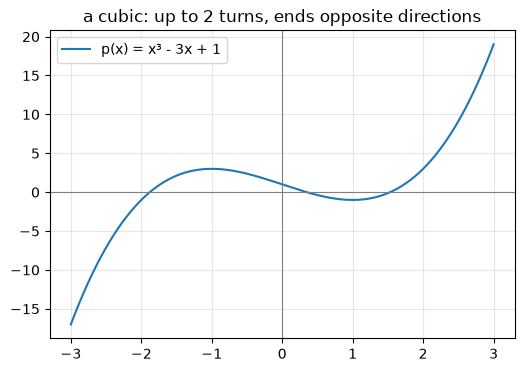

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# numpy represents a polynomial by its coefficient list, highest power first.
# Here: 1*x^3 + 0*x^2 - 3*x + 1  ->  [1, 0, -3, 1]
coeffs = [1, 0, -3, 1]
xv = np.linspace(-3, 3, 400)
yv = np.polyval(coeffs, xv)              # np.polyval evaluates the polynomial at every x at once

print("p(2) =", np.polyval(coeffs, 2))   # quick single evaluation

plt.figure(figsize=(6, 4))
plt.plot(xv, yv, label="p(x) = x³ - 3x + 1")
plt.axhline(0, color='gray', lw=0.8); plt.axvline(0, color='gray', lw=0.8)
plt.grid(alpha=0.3); plt.legend(); plt.title("a cubic: up to 2 turns, ends opposite directions")
plt.show()


## Summary — what you should now be able to do

1. Recognise a polynomial; name its **degree, leading coefficient, constant term, standard
   form**, and type (monomial/binomial/trinomial; linear/quadratic/cubic).
2. **Add and subtract** polynomials by combining like terms.
3. **Multiply** polynomials (distributive / FOIL).
4. Use and **prove** the special products: $(a\pm b)^2$ and $(a+b)(a-b)=a^2-b^2$.
5. Apply the **degree rules**: $\deg(pq)=\deg p+\deg q$, $\deg(p+q)\le\max$.
6. **Evaluate** polynomials and read the basic shape of their graphs.


## Exercises (20)

Try each yourself first. The last block asks for proofs.

**A. Identify**
1. For $p(x)=4 - x + 6x^4 - 2x^2$: write it in standard form, give its degree, leading coefficient, and constant term.
2. Classify by number of terms and by degree: $7x^2$, $\;x-9$, $\;x^3+2x^2-1$.
3. Is $3x^{-2}+1$ a polynomial? Is $\sqrt{x}+2$? Explain.
4. Give the constant term of $(x+2)(x-5)$ without fully expanding. (Hint: product of constants.)
5. What is the degree of the zero polynomial issue aside, of $5$ (a constant)?

**B. Add / subtract / multiply**
6. $(2x^2 + 3x - 1) + (x^2 - 4x + 6)$.
7. $(5x^3 - x + 2) - (3x^3 + 2x^2 - x)$.
8. $(x + 7)(x - 2)$.
9. $(2x - 3)(3x + 4)$.
10. $(x^2 + x - 1)(x - 2)$.

**C. Special products & evaluation**
11. Expand $(x+5)^2$.
12. Expand $(3x-2)^2$.
13. Expand $(x+6)(x-6)$.
14. Use a special product to compute $103 \times 97$ in your head (hint: $(100+3)(100-3)$).
15. Evaluate $p(x)=x^3 - 2x + 4$ at $x=-2$ and at $x=3$.

**D. Proofs / reasoning (raise the bar)**
16. Prove $(a-b)^2 = a^2 - 2ab + b^2$ starting from $(a-b)(a-b)$.
17. Prove $(a+b)^3 = a^3 + 3a^2b + 3ab^2 + b^3$. (Hint: $(a+b)^2(a+b)$.)
18. Prove that the product of two polynomials of degrees $m$ and $n$ has degree $m+n$.
19. Give an explicit example where $\deg(p+q) < \max(\deg p, \deg q)$, and explain exactly why the degree drops.
20. Prove that if $p(x)$ has degree $n$, then $p(x) - a_n x^n$ (subtract its leading term) has degree at most $n-1$.


In [7]:
# Your work for exercises 1-5 (identify). Use sp.Poly(...).degree(), .LC(), .all_coeffs().


In [8]:
# Your work for exercises 6-10 (add/subtract/multiply). Check with sp.expand(...).


In [9]:
# Your work for exercises 11-15 (special products & evaluation). Use .subs(x, value) to evaluate.


In [10]:
# Your work for exercises 16-20 (proofs). Write proofs in a markdown cell; use code only to test.


## How to run this notebook with `uv`

From the project folder `C:\dev\math`:

```powershell
uv sync                 # install dependencies (first time / after changes)
uv run jupyter lab      # open JupyterLab, then open notebooks/04-polynomials.ipynb
```

No new libraries this time. Add any future one with `uv add <name>`.
